# <u>Hierarchical Clustering</u>

## Topics

* [1. Goal of Hierarchical Clustering](#goal)
* [2. Two Types of Hierarchical Clustering](#types)
    * [2.1 Agglomerative (Bottom-up)](#up)
    * [2.2 Divisive (Top-down)](#down)
* [3. Key Components](#components)
* [4. Algorithm (Agglomerative)](#alg)
* [5. Dendrogram](#dendrogram)
* [6. Properties of Linkage Methods](#linkage)
* [7. Cluster Validation Measure](#eval)
* [8. Key Takeaways](#takeaway)
* [9. Hierarchical Clustering library](#library)


In [8]:
import numpy as np # for math and random numbers
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs # make data for classification
from sklearn.preprocessing import StandardScaler # for standardizing features
#from scipy.cluster.hierarchy import linkage, dendogram, fcluster
#import scipy.cluster.hierarchy as sch 
from sklearn.cluster import AgglomerativeClustering # bottom up clustering
from scipy.cluster.hierarchy import linkage, dendrogram
print("Setup complete")

Setup complete


<a class="anchor" id="goal"></a>
# 1. Goal of Hierarchical Clustering

- Group observations into clusters such that:
    - High similarity within clusters (homogeneity within clusters)
    - High dissimilarity between clusters (clusters far away from different clusters)

<p align="center">
<img src="pics\0.jpeg" width="600"/>
</p>

### Clustering vs. Classification
<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### Classification
- Labels are known
- Learn what differentiates data with different labels
- Learn a classification rule to classify future data




</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

##### Clustering
- Labels are unknown
- Find similar groups
- Looking for new insights in the data



</div>
</div>




<a class="anchor" id="types"></a>
# 2. Two Types of Hierarchical Clustering

**Hierarchical clustering recursively builds a hierarchy of clusters in two ways:**


<a class="anchor" id="up"></a>
## 2.1 Agglomerative (Bottom-up)


- Start with each observation as its own cluster
- Iteratively merge the two closest clusters
- End when all points are in one cluster



<a class="anchor" id="down"></a>
## 2.2 Divisive (Top-down)

- Start with all observations in one cluster
- Iteratively split clusters
- End when each observation is separate

<a class="anchor" id="components"></a>
# 3. Key Components

Given $n$ multivariate data points $x_1,\ldots,x_n$  with $p$ features (dimensions) with $X_i=(x_{i1},\ldots,x_{ip})^\top$ collected inside a $(n \times p)$ matrix.

$$
\begin{array}{ccc}
i & \text{feature 1} & \ldots & \text{feature p} \\
\hline
1 & x_{11} & \ldots & x_{1p} \\
\vdots & \vdots & \vdots \\
n & x_{n1} & \ldots & x_{np} \\
\end{array}
$$

#### Distance Between Observations $x_i$ and $x_j$

- Measures similarity:
    - Manhattan distance
    $$
    d(x_i,x_j)=\lVert x_i - x_j \rVert_1 = \sum_{k=1}^p \mid x_{ik} - x_{jk} \mid
    $$
    - Euclidean distance
    $$
    d(x_i,x_j)=\lVert x_i - x_j \rVert_2 = \sqrt{\sum_{k=1}^p (x_{ik} - x_{jk})^2 }
    $$
- <u>Important: Normalize data before computing distances</u>

<p align="center">
<img src="pics\1.png" width="600"/>
</p>


#### Distance Between Clusters (Linkage)

**The linkage of two clusters $C_r$ and $C_s$ is a score that describes their distance.**

Defines how clusters are merged:

- Single linkage: minimum pairwise distance
- Complete linkage: maximum pairwise distance
- Average linkage: average pairwise distance
- Centroid linkage: distance between cluster means

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/2.png" width="550"/>
  <img src="pics/3.png" width="550"/>
</div>

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/4.png" width="550"/>
  <img src="pics/5.png" width="550"/>
</div>

<a class="anchor" id="alg"></a>
# 4. Algorithm (Agglomerative)

1. Start with each point as its own cluster
2. Compute distances between clusters
3. Merge closest clusters
4. Repeat until one cluster remains

<p align="center">
<img src="pics\6.png" width="600"/>
</p>

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/7.png" width="550"/>
  <img src="pics/8.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/8.png" width="550"/>
  <img src="pics/10.png" width="550"/>
</div>




<a class="anchor" id="dendrogram"></a>
# 5. Dendrogram

- A tree diagram showing how clusters are merged
- Height = distance at which clusters merge
- Choose number of clusters by cutting the tree at a certain height

<p align="center">
<img src="pics\11.png" width="600"/>
</p>

In [ ]:
import numpy as np


# 1. Distance between observations
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))


# 2. Compute full distance matrix
def compute_distance_matrix(X, metric="euclidean"):
    n = len(X)
    D = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            if metric == "euclidean":
                d = euclidean_distance(X[i], X[j])
            elif metric == "manhattan":
                d = manhattan_distance(X[i], X[j])
            
            D[i, j] = D[j, i] = d
    return D


# 3. Linkage functions (cluster-to-cluster distance)
def single_linkage(C1, C2, D):
    return min(D[i, j] for i in C1 for j in C2)

def complete_linkage(C1, C2, D):
    return max(D[i, j] for i in C1 for j in C2)

def average_linkage(C1, C2, D):
    distances = [D[i, j] for i in C1 for j in C2]
    return np.mean(distances)



# 4. Agglomerative Hierarchical Clustering
def hierarchical_clustering(X, linkage="single", metric="euclidean"):
    n = len(X)
    
    # Step 1: each point is its own cluster
    clusters = [[i] for i in range(n)]
    
    # Precompute distances between points
    D = compute_distance_matrix(X, metric)
    
    # Choose linkage function
    if linkage == "single":
        linkage_func = single_linkage
    elif linkage == "complete":
        linkage_func = complete_linkage
    elif linkage == "average":
        linkage_func = average_linkage
    
    history = []  # store merges (for dendrogram-like output)
    
    # Step 2: iterate until one cluster remains
    while len(clusters) > 1:
        min_dist = float("inf")
        merge_pair = None
        
        # Find closest pair of clusters
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = linkage_func(clusters[i], clusters[j], D)
                
                if dist < min_dist:
                    min_dist = dist
                    merge_pair = (i, j)
        
        i, j = merge_pair
        
        # Merge clusters
        new_cluster = clusters[i] + clusters[j]
        
        # Save merge info (like dendrogram step)
        history.append((clusters[i], clusters[j], min_dist))
        
        # Remove old clusters and add new one
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)
    
    return history


# Run on toy data
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.8, 0.9],
    [0.9, 0.8],
    [0.5, 0.5]
])

history = hierarchical_clustering(X, linkage="average")

# Show merging steps
for step, (c1, c2, dist) in enumerate(history):
    print(f"Step {step+1}: merge {c1} and {c2} at distance {dist:.3f}")


# Extract K clusters manually (cut dendrogram)
def get_clusters(history, n_points, k):
    clusters = [[i] for i in range(n_points)]
    
    for step in range(n_points - k):
        c1, c2, _ = history[step]
        
        # find clusters to merge
        for cluster in clusters:
            if set(cluster) == set(c1):
                cluster1 = cluster
            if set(cluster) == set(c2):
                cluster2 = cluster
        
        clusters.remove(cluster1)
        clusters.remove(cluster2)
        clusters.append(cluster1 + cluster2)
    
    return clusters


# Example: get 2 clusters
clusters_k2 = get_clusters(history, n_points=len(X), k=2)
print("Clusters (k=2):", clusters_k2)

Step 1: merge [2] and [3] at distance 0.141
Step 2: merge [0] and [1] at distance 0.141
Step 3: merge [4] and [2, 3] at distance 0.500
Step 4: merge [0, 1] and [4, 2, 3] at distance 0.830
Clusters (k=2): [[0, 1], [4, 2, 3]]


In [6]:
# Distance between observations
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))


# Compute full distance matrix
def compute_distance_matrix(X, metric="euclidean"):
    n = len(X)
    D = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1, n):
            if metric == "euclidean":
                d = euclidean_distance(X[i], X[j])
            elif metric == "manhattan":
                d = manhattan_distance(X[i], X[j])
            
            D[i, j] = D[j, i] = d
    return D


# Linkage functions
def single_linkage(C1, C2, D):
    return min(D[i, j] for i in C1 for j in C2)

def complete_linkage(C1, C2, D):
    return max(D[i, j] for i in C1 for j in C2)

def average_linkage(C1, C2, D):
    distances = [D[i, j] for i in C1 for j in C2]
    return np.mean(distances)

def centroid_linkage(C1, C2, X):
    centroid1 = np.mean(X[C1], axis=0)
    centroid2 = np.mean(X[C2], axis=0)
    return euclidean_distance(centroid1, centroid2)


# Agglomerative Hierarchical Clustering
def hierarchical_clustering(X, linkage="single",metric="euclidean"):
    n = len(X)
    clusters = [[i] for i in range(n)]
    D = compute_distance_matrix(X,metric)
    
    history = []
    
    while len(clusters) > 1:
        min_dist = float("inf")
        merge_pair = None
        
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                
                if linkage == "single":
                    dist = single_linkage(clusters[i], clusters[j], D)
                elif linkage == "complete":
                    dist = complete_linkage(clusters[i], clusters[j], D)
                elif linkage == "average":
                    dist = average_linkage(clusters[i], clusters[j], D)
                elif linkage == "centroid":
                    dist = centroid_linkage(clusters[i], clusters[j], X)
                
                if dist < min_dist:
                    min_dist = dist
                    merge_pair = (i, j)
        
        i, j = merge_pair
        
        new_cluster = clusters[i] + clusters[j]
        history.append((clusters[i], clusters[j], min_dist))
        
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)
    
    return history


# Extract clusters (cut dendrogram)
def get_clusters(history, n_points, k):
    clusters = [[i] for i in range(n_points)]
    
    for step in range(n_points - k):
        c1, c2, _ = history[step]
        
        for cluster in clusters:
            if set(cluster) == set(c1):
                cluster1 = cluster
            if set(cluster) == set(c2):
                cluster2 = cluster
        
        clusters.remove(cluster1)
        clusters.remove(cluster2)
        clusters.append(cluster1 + cluster2)
    
    return clusters


# 7. Toy data
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.8, 0.9],
    [0.9, 0.8],
    [0.5, 0.5]])


# Run clustering (centroid linkage)
history = hierarchical_clustering(X, linkage="centroid")

for step, (c1, c2, dist) in enumerate(history):
    print(f"Step {step+1}: merge {c1} and {c2} at distance {dist:.3f}")


# Get clusters (k=2)
clusters_k2 = get_clusters(history, n_points=len(X), k=2)
print("Clusters (k=2):", clusters_k2)


# Convert cluster format to labels
labels = np.zeros(len(X))

for idx, cluster in enumerate(clusters_k2):
    for point in cluster:
        labels[point] = idx


# Plot 
fig = px.scatter(x=X[:, 0],y=X[:, 1],color=labels.astype(str),
                 title="Hierarchical Clustering (Centroid Linkage)",labels={"x": "Feature 1", "y": "Feature 2", "color": "Cluster"})
fig.show()

Step 1: merge [2] and [3] at distance 0.141
Step 2: merge [0] and [1] at distance 0.141
Step 3: merge [4] and [0, 1] at distance 0.495
Step 4: merge [2, 3] and [4, 0, 1] at distance 0.825
Clusters (k=2): [[2, 3], [4, 0, 1]]


<a class="anchor" id="linkage"></a>
# 6. Properties of Linkage Methods

- Single linkage
    - Can create long chains (chaining effect)
    - Clusters may be sparse
    <p align="center">
    <img src="pics\12.png" width="600"/>
    </p>
- Complete linkage
    - Produces dense clusters
    - May force clusters too close (crowding)
    <p align="center">
    <img src="pics\13.png" width="600"/>
    </p>
- Average linkage
    - Balance between single and complete
    - Often preferred in practice
    <p align="center">
    <img src="pics\14.png" width="600"/>
    </p>
- Centroid linkage
    - Uses cluster centers
    - Can produce inversions in dendrogram
    <p align="center">
    <img src="pics\15.png" width="600"/>
    </p>

<a class="anchor" id="eval"></a>
# 7. Cluster Validation Measure

Clustering goal: 
- (Average) distance within all clusters should be small
- (Average) distance between clusters should be large

<p align="center">
<img src="pics\0.jpeg" width="600"/>
</p>
Requirements for Validtation measures
- compactness measure to evaluate how close obseervations within clusters are
- separation measure to determine how well separated clusters are from other clusters

- combine both measures with weights $\alpha$ and $\beta$ as $$\text{index} = \frac{\alpha \cdot \text{separation}}{\beta \cdot \text{compactness}}$$ 

### Dunn index

$$
D=\frac{\text{separation}}{\text{compactness}}=\frac{\min_{i\neq j}d(C_i,C_j)}{\max_{k}d(\Delta C_k)}
$$

<p align="center">
<img src="pics\16.png" width="600"/>
</p>

- Separation $\min_{i\neq j}d(C_i,C_j)$
    - For each cluster compute the pairiwse distance between each observation inside a cluster and the observations in all other clusters
    - Use the minimum of those pairwise distances as separation measure

- Compactness $\max_{k}d(\Delta C_k)$
    - For each cluster compute the distance between the observation inside the same cluster 
    - Use the maximum of those distances as compactness measure


- Large $D$ indicates better clustering



### Silhouette coefficient

$$
S_i = \frac{b_i - a_i}{\max(a_i,b_i)}, \quad S_i \in [-1,1]
$$

- $a_i$ is the average distance between $i$ and all other observations of the cluster to which $i$ belongs
- $b_i=min_{C(i)\neq k}d(C(i),C_k)$
    - $d(C(i),C_k)$ is average distance between observation $i$ from cluster $C(i)$ to all observations in cluster $C_k$ to which $i$ does not belong
    - $b_i$ can be seen as the distance between $i$ and its closest cluster to which $i$ does not belong
- A high average silhouette value indicates better clustering


<a class="anchor" id="takeaway"></a>
# 8. Key Takeaways

- Hierarchical clustering builds a hierarchy of clusters, not just one partition
- Hierarchical agglomerative cluster methods iteratively merges observations until all observations are in a single cluster
- No need to predefine number of clusters
- A dendogram shows the hierarchy of all possible cluster assignments
- Each node of the dendogram represents a cluster and its height is proportional to the distance of its child nodes
- Final clustering obtained by cutting the dendrogram
- Choice of distance + linkage strongly affects results
- Single, complete,average and centroid linkage each have advantages and disadvantages
- No universally best method — depends on data

<a class="anchor" id="library"></a>
# 9. Hierarchical Clustering library

```python
# 1. Import Hierarchical Clustering tools
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

# Example distance matrix (optional)
dist_matrix = pdist(X, metric="euclidean") # or "cityblock" for Manhattan


# 2. Perform Agglomerative Clustering
Z = linkage(X, method="ward")  
# methods: "single", "complete", "average", "ward"


# 3. Plot Dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()


# 4. Cut Dendrogram into K clusters
clusters_k = fcluster(Z, t=3, criterion="maxclust") # choose k=3 clusters


# 5. Cut by Distance Threshold
clusters_d = fcluster(Z, t=5.0, criterion="distance") # distance threshold


# 6. Compare Linkage Methods
methods = ["single", "complete", "average", "ward"]

for m in methods:
    Z_m = linkage(X, method=m)
    plt.figure()
    dendrogram(Z_m)
    plt.title(f"Dendrogram ({m} linkage)")
    plt.show()


# 7. Using sklearn (AgglomerativeClustering)
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=3,
    metric="euclidean",
    linkage="ward" # "single", "complete", "average"
)

labels = model.fit_predict(X)


# 8. Visualize Clusters (2D)
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("Hierarchical Clustering")
plt.show()


# 9. Standardization (important!)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z_scaled = linkage(X_scaled, method="ward")


# 10. Pipeline (with preprocessing)
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("cluster", AgglomerativeClustering(n_clusters=3))
])

labels_pipeline = pipeline.fit_predict(X)


# 11. Distance Metrics Comparison
for metric in ["euclidean", "cityblock", "cosine"]:
    dist = pdist(X, metric=metric)
    Z_metric = linkage(dist, method="average")
    plt.figure()
    dendrogram(Z_metric)
    plt.title(f"Dendrogram ({metric})")
    plt.show()


# 12. Extract Cluster Assignments for different K
for k in [2, 3, 4, 5]:
    clusters = fcluster(Z, t=k, criterion="maxclust")
    print(f"k={k}:", clusters[:10]) # first 10 labels


# 13. Toy Example
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    random_state=1415
)

Z = linkage(X, method="ward")

plt.figure()
dendrogram(Z)
plt.title("Toy Data Dendrogram")
plt.show()
```

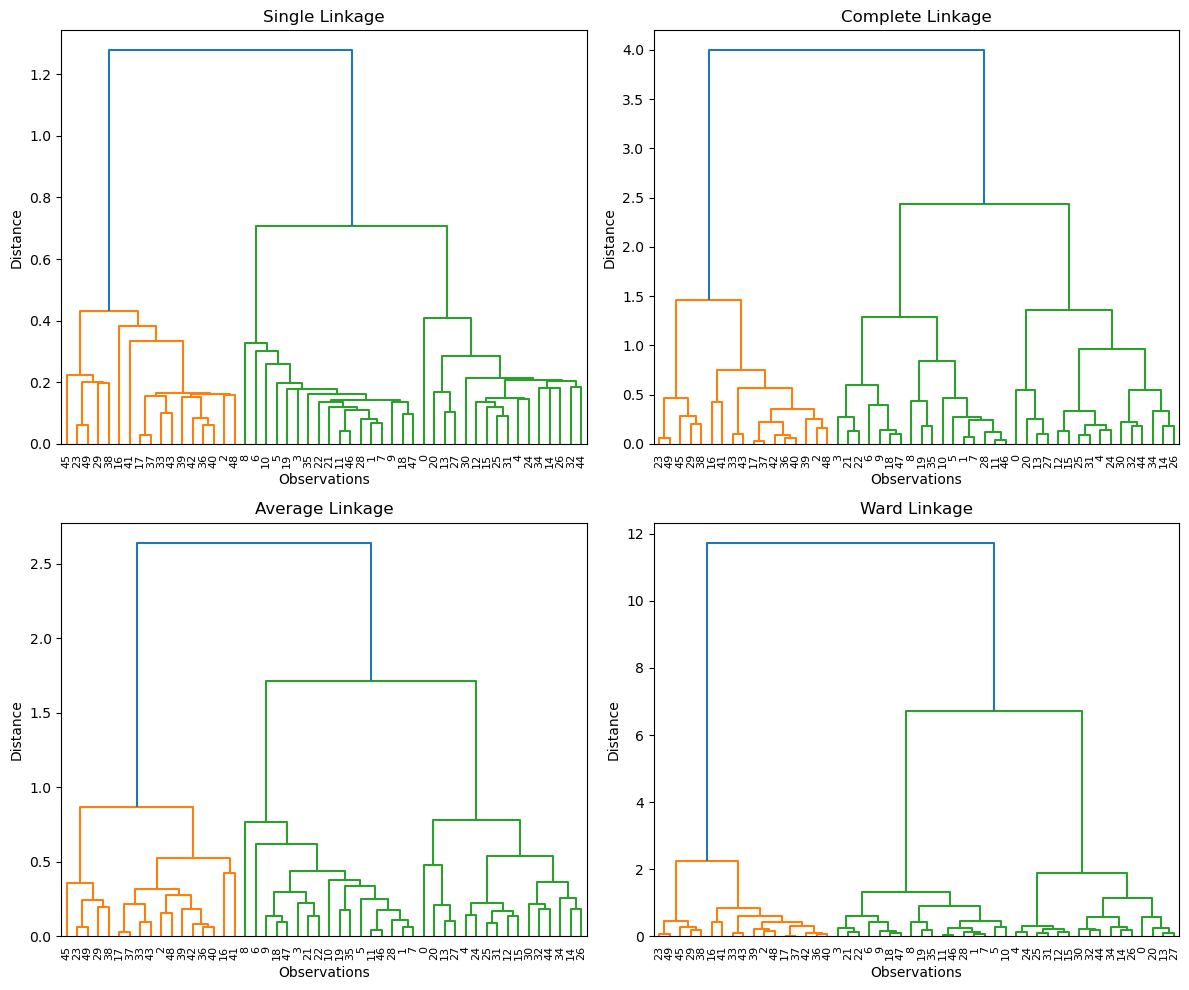

In [13]:
# Generate toy data
X, y = make_blobs(n_samples=50,centers=3,n_features=2,random_state=1415)

# Standardize data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Linkage methods to compare
methods = ["single", "complete", "average", "ward"]

# Plot dendrograms for each linkage method
plt.figure(figsize=(12, 10))

for i, method in enumerate(methods, 1):
    Z = linkage(X_scaled, method=method)
    plt.subplot(2, 2, i)
    dendrogram(Z)
    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Observations")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()